In [1]:
import matplotlib.pyplot as plt
import numpy as np

import scarf

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_10K_pbmc-v1_atacseq',
    destination='scarf_datasets'
)

Downloading bucket files: 79995014 / 79995014 complete

Downloading bytes: 79995014 / 79995014 complete

In [3]:
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
    mem_budget="8G",
)
writer.dump()

Writing counts: 4 / 4 complete

In [5]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4
)

Computing ATAC initialization statistics: 4 / 4 complete

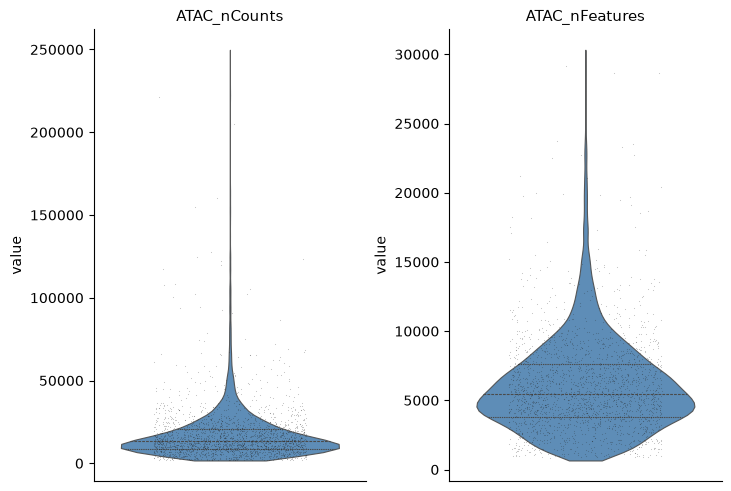

In [6]:
qc_cols = [
    c for c in ('ATAC_nCounts', 'ATAC_nFeatures')
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

In [7]:
n_before = int(ds.cells.fetch_all('I').sum())
cell_selection = ds.auto_filter_cells()
cell_mask = np.asarray(ds.load_artifact(cell_selection)['values'][:], dtype=bool)
print(f'Cells in input selection: {n_before}')
print(f'Cells after filter: {int(cell_mask.sum())}')

Cells in input selection: 8728
Cells after filter: 8426


In [8]:
peak_features = ds.select_prevalent_peaks(cell_selection, top_n=25000)
peak_values = np.asarray(ds.load_artifact(peak_features)['values'][:])
print('Selected peaks:', int(peak_values.sum()))

(ATAC) Calculating peak prevalence across cells: 4 / 4 complete

Selected peaks: 25000


In [9]:
normalized = ds.run_normalization(cell_selection, peak_features)
lsi = ds.run_lsi(normalized, dims=50, skip_first=True)
initialization = ds.build_embedding_initialization(lsi)
ann_index = ds.build_ann_index(lsi)
neighbors = ds.query_neighbors(ann_index, k=21)
graph = ds.build_connectivity_map(neighbors)

ds.load_graph(graph)

(ATAC) Computing document frequency across selected cells: 4 / 4 complete

Writing data: 7 / 7 complete

Fitting streaming LSI model (1/7): 7 / 7 complete

Fitting streaming LSI model (2/7): 7 / 7 complete

Fitting streaming LSI model (3/7): 7 / 7 complete

...

Calculating reduced coordinates: 7 / 7 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 176946 stored elements and shape (8426, 8426)>

In [10]:
umap = ds.run_umap(
    graph,
    initialization,
    n_epochs=500,
    min_dist=0.1, 
    spread=1, 
    parallel=True
)

Training UMAP: 500 / 500 complete

In [11]:
clusters = ds.run_leiden_clustering(graph, resolution=0.6)
cluster_values = np.asarray(ds.load_artifact(clusters)['values'][:])
np.unique(cluster_values, return_counts=True)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 array([2827,  179,  734,  385,  150,  786, 1081, 1191,   70,  299,   36,
         480,  208]))

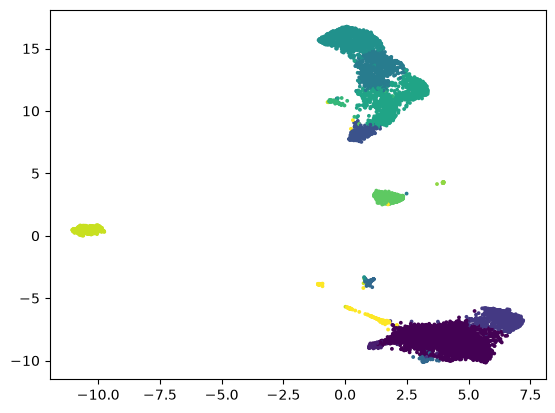

In [12]:
umap_values = np.asarray(ds.load_artifact(umap)['values'][:])
plt.scatter(umap_values[:, 0], umap_values[:, 1], c=cluster_values, s=3)

In [13]:
annotations = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='annotations',
    destination='scarf_datasets'
)

Downloading bucket files: 4397159 / 4397159 complete

Downloading bytes: 4397159 / 4397159 complete

In [14]:
ds.add_melded_assay(
    from_assay='ATAC',
    external_bed_fn=f'{annotations}/human_GRCh37_gencode_v38_gene_body.bed.gz',
    peaks_col='ids',
    renormalization=False,
    assay_label='GeneScores',
    assay_type='RNA'
)
print(
    'Valid GeneScores features:',
    int(ds.GeneScores.feats.fetch_all('I').sum()),
)

Writing gene scores: 10 / 10 complete

Melding assay: 10 / 10 complete

Computing GeneScores initialization statistics: 10 / 10 complete

Valid GeneScores features: 62446
